In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pickle
import matplotlib.pyplot as plt
import mcfile as mcf
import pickle
from scipy.spatial.distance import cdist
import pandas as pd
from ensemble_rbm import load_ensemble_results

In [2]:
def visualize_torus_modes(U_K, sector_name, L=24):
    """
    Plots the top 2 principal components as 2D spatial maps on the torus.
    U_K shape: (V, K) where V = L*L
    """
    # Extract the first two principal components
    mode_1 = U_K[:, 0].reshape(L, L)
    mode_2 = U_K[:, 1].reshape(L, L)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Mode 1
    im1 = axes[0].imshow(mode_1, cmap='RdBu', origin='lower')
    axes[0].set_title(f"{sector_name} - Dominant Mode 1")
    fig.colorbar(im1, ax=axes[0])
    
    # Mode 2
    im2 = axes[1].imshow(mode_2, cmap='RdBu', origin='lower')
    axes[1].set_title(f"{sector_name} - Dominant Mode 2")
    fig.colorbar(im2, ax=axes[1])
    
    plt.suptitle(f"Spatial Visualization of Normal Modes on the Torus")
    plt.tight_layout()
    plt.show()

def compute_weak_coupling_J(W, bh):
    """
    Computes the effective pairwise J matrix in the small-weight limit
    when W is shaped as (H, V).
    """
    # W shape: (H, V) where H is hidden, V is visible
    H, V = W.shape
    
    # Compute the variance of the hidden units: shape (H,)
    sigma = jax.nn.sigmoid(bh)
    variance = sigma * (1.0 - sigma) 
    # scale across hidden dim
    W_scaled = W * jnp.sqrt(variance)[:, None]
    
    # Since W_scaled is (H, V), to get a (V, V) interaction matrix,
    # J sim Wt cdot W (V, H) @ (H, V)
    J = (1.0 / 8.0) * jnp.dot(W_scaled.T, W_scaled)
    
    # Zero out diagonal to avoid self-interaction loops
    J = J * (1.0 - jnp.eye(V))
    return J

def compute_gaussian_metric_matrix(W, bh):
    """
    Computes the effective continuous metric matrix G = I - 4J
    directly from the W shape (H, V).
    """
    H, V = W.shape
    sigma = jax.nn.sigmoid(bh)
    variance = sigma * (1.0 - sigma)
    
    # Scaled matrix product matching the weak-coupling J
    W_scaled = W * jnp.sqrt(variance)[:, None]
    J = (1.0 / 8.0) * jnp.dot(W_scaled.T, W_scaled)
    
    # G = I - 4J
    return jnp.eye(V) - 4.0 * J

def sample_from_sector_pca(key, sector_instances, K, num_samples=1000):
    """
    Computes a collective PCA basis for a given sector by averaging its 
    analytic J matrices, then samples configurations along those top K modes.
    """
    # Grab dimensions from the first instance
    sample_W, sample_bv, sample_bh = sector_instances[0]
    H, V = sample_W.shape
    
    # 1. Accumulate and average the analytic J matrices across all instances in this sector
    J_total = jnp.zeros((V, V))
    for W, bv, bh in sector_instances:
        # Ensure data is converted to device arrays
        W_arr = jnp.array(W, dtype=jnp.float32)
        bh_arr = jnp.array(bh, dtype=jnp.float32)
        J_total += compute_weak_coupling_J(W_arr, bh_arr)
        
    J_avg = J_total / len(sector_instances)
    
    # 2. Extract principal components via EIGH
    eigenvalues, eigenvectors = jnp.linalg.eigh(J_avg)
    
    # Sort from largest to smallest eigenvalue
    eigenvalues = jnp.flip(eigenvalues)
    U = jnp.flip(eigenvectors, axis=1)
    
    # Truncate to top K principal directions
    U_K = U[:, :K]
    sigma_K = jnp.sqrt(jnp.abs(eigenvalues[:K])) # Standard deviation of the modes
    
    # 3. Sample continuous fluctuations in the latent subspace
    k1, k2 = jax.random.split(key)
    latent_samples = jax.random.normal(k1, (num_samples, K)) * sigma_K[None, :]
    
    # 4. Project back to physical real-space and squash to binary boundaries [0, 1]
    v_mean = 0.5 * jnp.ones((V,))
    v_continuous = v_mean[None, :] + jnp.dot(latent_samples, U_K.T)
    v_sampled_configs = jax.nn.sigmoid(v_continuous)
    
    return v_sampled_configs, U_K, eigenvalues

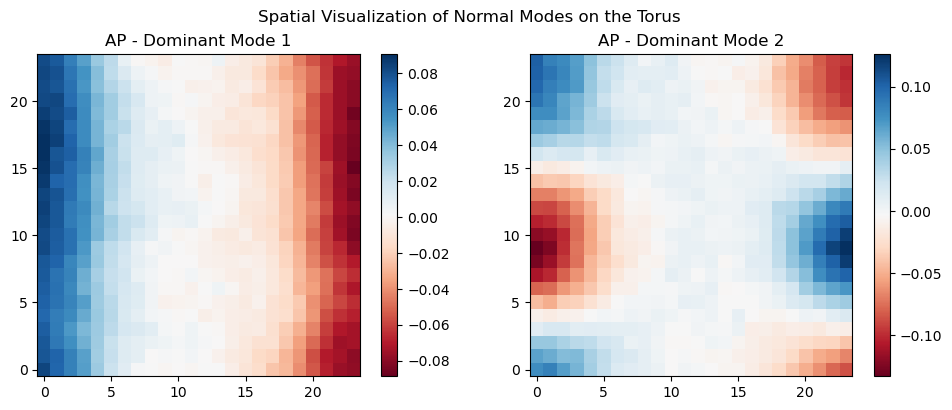


Sector: AP
-> Top 3 Eigenvalues: [1.4774178 1.0929053 1.0430615]


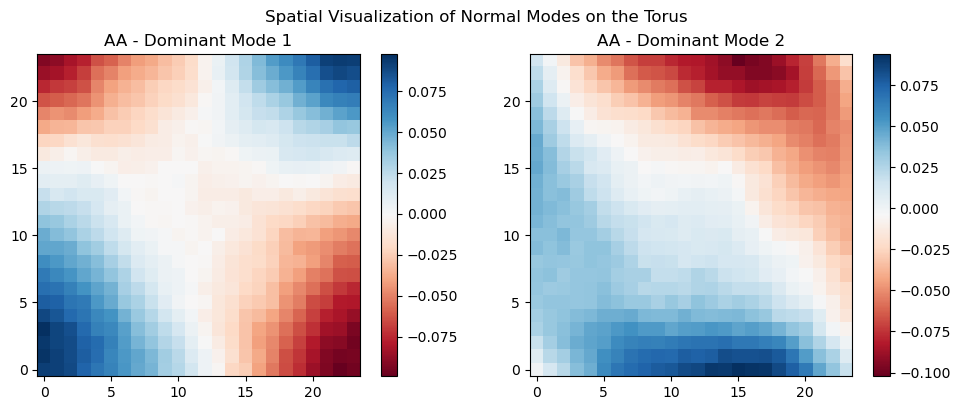


Sector: AA
-> Top 3 Eigenvalues: [1.6603401 1.5570903 1.5216774]


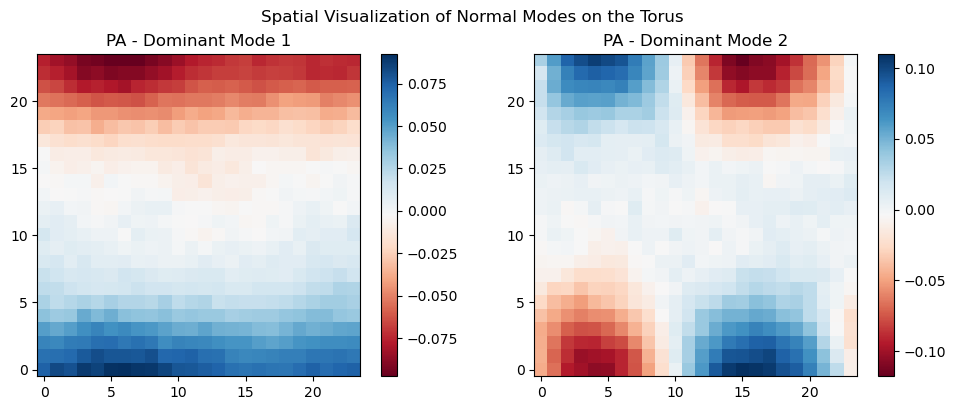


Sector: PA
-> Top 3 Eigenvalues: [1.4929509 1.1504973 1.0544966]


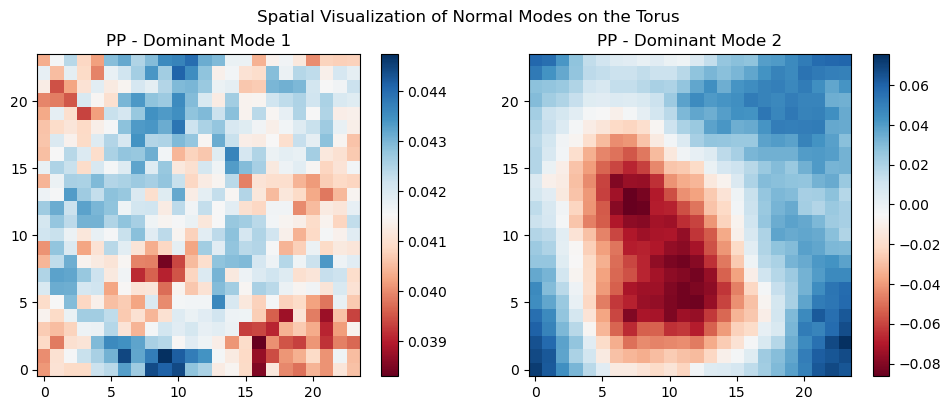


Sector: PP
-> Top 3 Eigenvalues: [2.5550137  0.47545534 0.45632568]


In [3]:
directory = '/home/shailesh/Projects/Local/BoltzmannMachine/ising_576_statistics/'
ens_results = load_ensemble_results(directory)
sectors = ens_results.keys()

hamiltonian_data = {}
for sector, ens in ens_results.items():
    hamiltonian_data[sector] = []
    for instance in ens:
        hamiltonian_data[sector].append((instance['W'],instance['bv'],instance['bh']))

            
# Process and sample
rng_key = jax.random.PRNGKey(1234)
K_modes = 3  # Keep the top 4 dominant modes

sampled_results = {}
for sector, instances in hamiltonian_data.items():
    rng_key, subkey = jax.random.split(rng_key)
    
    v_samples, U_K, spectrum = sample_from_sector_pca(subkey, instances, K=K_modes, num_samples=5)
    sampled_results[sector] = v_samples
    visualize_torus_modes(U_K, sector)
    
    print(f"\nSector: {sector}")
    print(f"-> Top {K_modes} Eigenvalues: {spectrum[:K_modes]}")